# 🎬 Predicting Movie Success: Estimating Weighted Rating Using Machine Learning

In this notebook, I will perform exploratory data analysis (EDA) and apply various machine learning algorithms to address the following problem:

> **Can we accurately predict the weighted rating of a movie based on its metadata, content attributes, and production details?**

The target variable for this analysis is **`weighted_rating`**, a numerical score representing the overall quality of a movie — likely derived from both user ratings and vote counts. The goal is to use all other available features (e.g., runtime, budget, genres, production companies, etc.) to build a predictive model that estimates this score **before** the movie is released.

This process will include:

* Exploratory data analysis and feature understanding
* Preprocessing and feature engineering
* Building and comparing different machine learning models
* Evaluating model performance using regression metrics
* Drawing conclusions and possible next steps

In [14]:
# Basic imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import re, time, random, datetime, math
from datetime import datetime
from tqdm import tqdm

##################### Preprocessing imports 
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2
from sklearn.feature_selection import mutual_info_classif, mutual_info_regression
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from category_encoders import TargetEncoder, HashingEncoder, CountEncoder
from sklearn.impute import KNNImputer

##################### Metrics
from sklearn.metrics import make_scorer, mean_squared_error, mean_absolute_error
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

##################### Models
from xgboost import XGBClassifier, XGBRegressor
from catboost import CatBoostClassifier, CatBoostRegressor
from lightgbm import LGBMClassifier, LGBMRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import make_pipeline

##################### Model selection 
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.gaussian_process.kernels import RBF, Matern, RationalQuadratic
from sklearn.model_selection import StratifiedKFold, KFold, RepeatedStratifiedKFold
from sklearn.model_selection import train_test_split
from sklearn.ensemble import VotingRegressor
from sklearn.inspection import permutation_importance
from sklearn.base import clone
from sklearn.metrics import mean_squared_error, r2_score
from scipy.optimize import minimize
from IPython.display import clear_output
from concurrent.futures import ThreadPoolExecutor
from scipy.stats import skew, kurtosis

##################### optuna library import
import optuna
import shap
import matplotlib.cm as cm
from collections import defaultdict
from currency_converter import CurrencyConverter

##################### Basic settings
random_state = 42

In [15]:
data = pd.read_csv('tmdb_movies_cleaned.csv')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9953 entries, 0 to 9952
Data columns (total 46 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          9953 non-null   int64  
 1   title                       9953 non-null   object 
 2   runtime                     9953 non-null   int64  
 3   release_date                9953 non-null   object 
 4   budget                      9953 non-null   int64  
 5   revenue                     9953 non-null   int64  
 6   popularity                  9953 non-null   float64
 7   vote_average                9953 non-null   float64
 8   vote_count                  9953 non-null   int64  
 9   belongs_to_collection       9953 non-null   int64  
 10  has_tagline                 9953 non-null   int64  
 11  has_homepage                9953 non-null   int64  
 12  num_same_title              9953 non-null   int64  
 13  changed_title               9953 

In [ ]:
data['belongs_to_collection'] = data['belongs_to_collection'].astype(bool)
data['has_tagline'] = data['has_tagline'].astype(bool)
data['has_homepage'] = data['has_homepage'].astype(bool)
data['has_homepage'] = data['has_homepage'].astype(bool)
data['release_date'] = pd.to_datetime(data['release_date'], errors='coerce')

# Extract release year (if not already present)
data['release_year'] = data['release_date'].dt.year

# Create release_decade column
data['release_decade'] = (data['release_year'] // 10) * 10

# Convert to string for categorical plotting (e.g. '1990s')
data['release_decade'] = data['release_decade'].astype('Int64').astype(str) + 's'



# Regression -> lets look at the label as numeric-consistance value (later on i will bin it and use it as catagorical)

Summary statistics for 'weighted_rating':


count    9953.000000
mean        6.442062
std         0.618833
min         3.057064
25%         6.092196
50%         6.356828
75%         6.795872
max         8.699763
Name: weighted_rating, dtype: float64

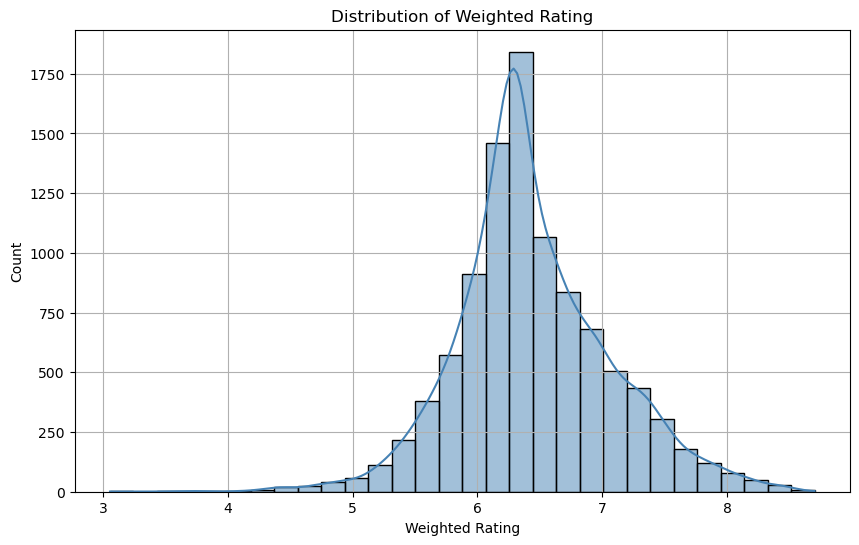

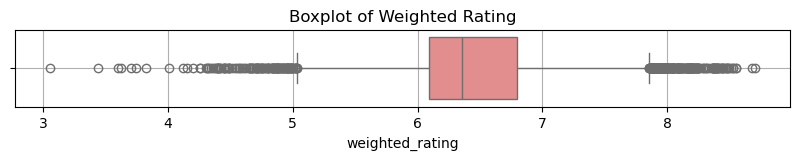

Skewness: 0.218
Kurtosis: 0.980


In [17]:
# Basic statistics
print("Summary statistics for 'weighted_rating':")
display(data['weighted_rating'].describe())

# Distribution plot
plt.figure(figsize=(10, 6))
sns.histplot(data['weighted_rating'], bins=30, kde=True, color='steelblue')
plt.title('Distribution of Weighted Rating')
plt.xlabel('Weighted Rating')
plt.ylabel('Count')
plt.grid(True)
plt.show()

# Boxplot for outlier detection
plt.figure(figsize=(10, 1))
sns.boxplot(x=data['weighted_rating'], color='lightcoral')
plt.title('Boxplot of Weighted Rating')
plt.grid(True)
plt.show()

# Skewness and kurtosis
skewness = skew(data['weighted_rating'])
kurt = kurtosis(data['weighted_rating'])

print(f"Skewness: {skewness:.3f}")
print(f"Kurtosis: {kurt:.3f}")


## Lets find the strong corrolations between all the numeric features and our label|

/var/folders/f0/l96rg_wj4qvg_lzh89qycdgc0000gn/T/ipykernel_66225/1771481693.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlations.values, y=correlations.index, palette='coolwarm')


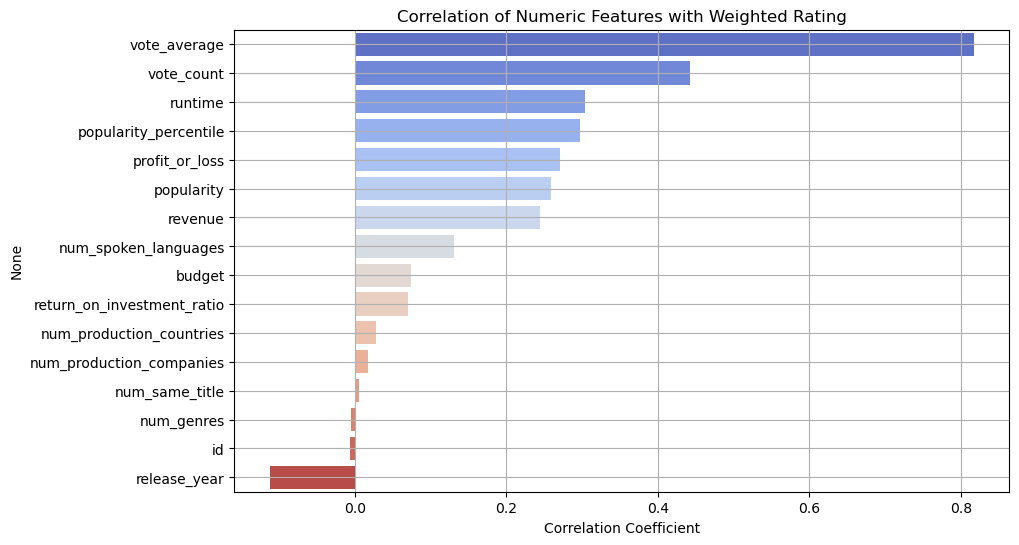

,correlation
vote_average,0.817501
vote_count,0.442431
runtime,0.304351
popularity_percentile,0.297037
profit_or_loss,0.271187
popularity,0.258900
revenue,0.244237
num_spoken_languages,0.130757
budget,0.073851
return_on_investment_ratio,0.070693


In [18]:
# Select only numerical columns (excluding the target for now)
numeric_cols = data.select_dtypes(include=['int64', 'float64']).drop(columns=['weighted_rating'])

# Compute correlation with target
correlations = numeric_cols.corrwith(data['weighted_rating']).sort_values(ascending=False)

# Plot correlation values
plt.figure(figsize=(10, 6))
sns.barplot(x=correlations.values, y=correlations.index, palette='coolwarm')
plt.title('Correlation of Numeric Features with Weighted Rating')
plt.xlabel('Correlation Coefficient')
plt.grid(True)
plt.show()

# Display top correlated features
display(correlations.to_frame(name='correlation').style.background_gradient(cmap='coolwarm'))


| Feature                 | Correlation | Notes                                                                                                         |
| ----------------------- | ----------- | ------------------------------------------------------------------------------------------------------------- |
| **`vote_average`**      | **0.82** ⚠️   | As expected — it likely feeds directly into the weighted rating formula (could be redundant or even leakage!) |
| `vote_count`            | 0.44 ✅      | More votes = more stable and possibly higher credibility                                                      |
| `runtime`               | 0.30 ✅      | Longer movies may be rated more seriously                                                                     |
| `popularity_percentile` | 0.30 ✅      | Popular movies tend to be better known and attract more attention                                             |
| `profit_or_loss`        | 0.27        | Some correlation with success, but not a strong proxy                                                         |
| `popularity`            | 0.26        | Similar to percentile, but more raw and potentially skewed                                                    |
| `revenue`               | 0.24        | Slightly correlated, but not dominant (big budgets ≠ quality)                                                 |


### As we can see our label and vote_average feature has a significantly higher corrolation. we can assume that the feature is leakage variable, because weighted_rating is often calculated as a blend of vote_average and vote_count.

## Lets explore hoe catagoric features relate to the avarage wirghted_rating

In [ ]:
df_categories = data.copy()



df_categories.drop(columns=['release_date', 'release_year', 'changed_title', 'title'], inplace=True)  # Drop original date column if not needed

# Select categorical + boolean columns (excluding the target)
cat_bool_cols = df_categories.select_dtypes(include=['object', 'bool']).columns + ['num_same_title' 'num_production_companies' 'num_production_countries' 'num_spoken_languages' 'num_genres']
display(cat_bool_cols)

# Create a plot for each categorical feature
for col in cat_bool_cols:
    plt.figure(figsize=(10, 4))
    order = df_categories.groupby(col)['weighted_rating'].mean().sort_values(ascending=False).index
    sns.barplot(data=df_categories, x=col, y='weighted_rating', order=order, ci='sd', palette='viridis')
    plt.title(f'Average Weighted Rating by {col}')
    plt.xticks(rotation=45, ha='right')
    plt.grid(True, axis='y')
    plt.tight_layout()
    plt.show()


Index(['belongs_to_collectionnum_same_titlenum_production_companiesnum_production_countriesnum_spoken_languagesnum_genres',
       'has_taglinenum_same_titlenum_production_companiesnum_production_countriesnum_spoken_languagesnum_genres',
       'has_homepagenum_same_titlenum_production_companiesnum_production_countriesnum_spoken_languagesnum_genres',
       'Comedynum_same_titlenum_production_companiesnum_production_countriesnum_spoken_languagesnum_genres',
       'Actionnum_same_titlenum_production_companiesnum_production_countriesnum_spoken_languagesnum_genres',
       'Animationnum_same_titlenum_production_companiesnum_production_countriesnum_spoken_languagesnum_genres',
       'Dramanum_same_titlenum_production_companiesnum_production_countriesnum_spoken_languagesnum_genres',
       'Historynum_same_titlenum_production_companiesnum_production_countriesnum_spoken_languagesnum_genres',
       'Familynum_same_titlenum_production_companiesnum_production_countriesnum_spoken_languagesnum

KeyError: 'belongs_to_collectionnum_same_titlenum_production_companiesnum_production_countriesnum_spoken_languagesnum_genres'

<Figure size 1000x400 with 0 Axes>

### no effect at 